# Diabetes Prediction — Exploratory Data Analysis (Part 2)

**Follow-up to:** `diabetes_analysis.ipynb`

This notebook picks up where the previous script left off. The first notebook loaded the three BRFSS2021 diabetes datasets and produced basic univariate histograms and binary-variable proportions for each of them.

This notebook goes deeper, with one specific goal: **prepare the ground for a machine learning model that predicts diabetes status as one of three classes — No Diabetes, Prediabetes, or Diabetes.**

That three-class target (`Diabetes_012`) only exists in `diabetes_012_health_indicators_BRFSS2021.csv`, so this EDA concentrates on that dataset, while still cross-checking a couple of things against the two binary datasets for consistency.

**Scope of this notebook:** exploratory analysis and data-preparation diagnostics only — data quality, class balance, distributions, outliers, relationships between features and the target, redundancy between features, and a preliminary feature-relevance screen. **No model is trained here.** The actual predictive modeling is being handled separately.

**Environment:** same packages and data sources as the previous notebook (pandas, numpy, matplotlib, seaborn, plotly), plus `scipy` for statistical tests, `scikit-learn` for a mutual-information screen, and `statsmodels` for multicollinearity (VIF).


In [1]:
%pip install seaborn plotly scikit-learn scipy statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


## 1. Load data

Same three source files as the previous notebook, loaded fresh so this notebook can run independently.

In [2]:
df_1 = pd.read_csv("https://raw.githubusercontent.com/lasyaharini-cloud/Diabetes-Prediction/main/data/diabetes_012_health_indicators_BRFSS2021.csv")
df_2 = pd.read_csv("https://raw.githubusercontent.com/lasyaharini-cloud/Diabetes-Prediction/main/data/diabetes_binary_5050split_health_indicators_BRFSS2021.csv")
df_3 = pd.read_csv("https://raw.githubusercontent.com/lasyaharini-cloud/Diabetes-Prediction/main/data/diabetes_binary_health_indicators_BRFSS2021.csv")

print(f"df_1 (Diabetes_012, 3-class):            {df_1.shape}")
print(f"df_2 (Diabetes_binary, 50/50 split):      {df_2.shape}")
print(f"df_3 (Diabetes_binary, full/imbalanced):  {df_3.shape}")


df_1 (Diabetes_012, 3-class):            (236378, 22)
df_2 (Diabetes_binary, 50/50 split):      (67136, 22)
df_3 (Diabetes_binary, full/imbalanced):  (236378, 22)


### Why this notebook focuses on `df_1`

The ML task is a **3-class** prediction problem (negative / prediabetes / positive). Only `df_1` carries that label (`Diabetes_012` ∈ {0, 1, 2}); `df_2` and `df_3` collapse it to a binary `Diabetes_binary`. From here on, `df_1` is the primary dataset. `df_2`/`df_3` are brought back briefly in Section 8 only to sanity-check that the binary collapse is consistent with `df_1`.

In [3]:
TARGET = "Diabetes_012"
target_names = {0: "No Diabetes", 1: "Prediabetes", 2: "Diabetes"}

df = df_1.copy()
df["Diabetes_label"] = df[TARGET].map(target_names)
df.head()


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_label
0,0.0,0,1.0,1,15.0,1.0,0.0,0.0,0,1,1,0,1,0.0,5.0,10.0,20.0,0.0,0,11,4.0,5.0,No Diabetes
1,2.0,1,0.0,1,28.0,0.0,0.0,1.0,0,1,0,0,1,0.0,2.0,0.0,0.0,0.0,0,11,4.0,3.0,Diabetes
2,2.0,1,1.0,1,33.0,0.0,0.0,0.0,1,1,1,0,1,0.0,2.0,10.0,0.0,0.0,0,9,4.0,7.0,Diabetes
3,2.0,0,1.0,1,29.0,0.0,1.0,1.0,1,1,1,0,1,0.0,5.0,0.0,30.0,1.0,1,12,3.0,4.0,Diabetes
4,0.0,0,0.0,1,24.0,1.0,0.0,0.0,0,0,0,0,1,0.0,3.0,0.0,0.0,1.0,1,13,5.0,6.0,No Diabetes


## 2. Data quality checks

Before looking at any relationships, we check the basics that directly affect how the data needs to be cleaned before modeling: types, missing values, duplicate rows, and constant/near-constant columns.

In [4]:
print("Shape:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)


Shape: (236378, 23)

Dtypes:
Diabetes_012            float64
HighBP                    int64
HighChol                float64
CholCheck                 int64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity              int64
Fruits                    int64
Veggies                   int64
HvyAlcoholConsump         int64
AnyHealthcare             int64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                       int64
Age                       int64
Education               float64
Income                  float64
Diabetes_label              str
dtype: object


In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(3)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_count", ascending=False)

if missing_report.empty:
    print("No missing values in any column.")
else:
    print(missing_report)


No missing values in any column.


In [6]:
n_dupes = df.duplicated(subset=df_1.columns).sum()
pct_dupes = round(n_dupes / len(df) * 100, 2)
print(f"Fully duplicated rows: {n_dupes} ({pct_dupes}% of the dataset)")

dupe_by_class = df.loc[df.duplicated(subset=df_1.columns, keep=False)].groupby("Diabetes_label").size()
print("\nDuplicated rows broken down by class (before any dedup decision):")
print(dupe_by_class)


Fully duplicated rows: 12828 (5.43% of the dataset)



Duplicated rows broken down by class (before any dedup decision):
Diabetes_label
Diabetes         338
No Diabetes    20599
Prediabetes       12
dtype: int64


**Note for the modeling stage:** BRFSS is a survey of a large population sampled from a relatively small set of discrete/ordinal answer options (most features are binary 0/1 or coded on short ordinal scales), so a meaningful fraction of exact-duplicate rows is *expected* even between genuinely different respondents — it isn't necessarily a data-entry error. Whether to drop these duplicates (and whether to do it before or after a train/test split, to avoid leakage) is a modeling decision, flagged here rather than resolved.

In [7]:
nunique = df_1.nunique().sort_values()
print("Unique value counts per column (lowest first):")
print(nunique)

constant_cols = nunique[nunique == 1].index.tolist()
print(f"\nConstant columns (no variance, would need to be dropped): {constant_cols if constant_cols else 'none'}")


Unique value counts per column (lowest first):
HighBP                   2
HighChol                 2
CholCheck                2
Smoker                   2
HeartDiseaseorAttack     2
Stroke                   2
Fruits                   2
PhysActivity             2
AnyHealthcare            2
NoDocbcCost              2
Veggies                  2
HvyAlcoholConsump        2
Sex                      2
DiffWalk                 2
Diabetes_012             3
GenHlth                  5
Education                6
Income                  11
Age                     13
MentHlth                31
PhysHlth                31
BMI                     84
dtype: int64

Constant columns (no variance, would need to be dropped): none


## 3. Target variable: class balance

This is the single most important thing to establish before modeling — it determines whether resampling, class weighting, or a stratified split/evaluation metric (e.g. macro-F1 instead of accuracy) will be needed.

In [8]:
counts = df[TARGET].value_counts().sort_index()
pct = (counts / len(df) * 100).round(2)
balance_table = pd.DataFrame({"class": [target_names[i] for i in counts.index],
                               "count": counts.values,
                               "pct": pct.values})
print(balance_table.to_string(index=False))

imbalance_ratio = counts.max() / counts.min()
print(f"\nMajority:minority imbalance ratio = {imbalance_ratio:.1f} : 1")


      class  count   pct
No Diabetes 197191 83.42
Prediabetes   5619  2.38
   Diabetes  33568 14.20

Majority:minority imbalance ratio = 35.1 : 1


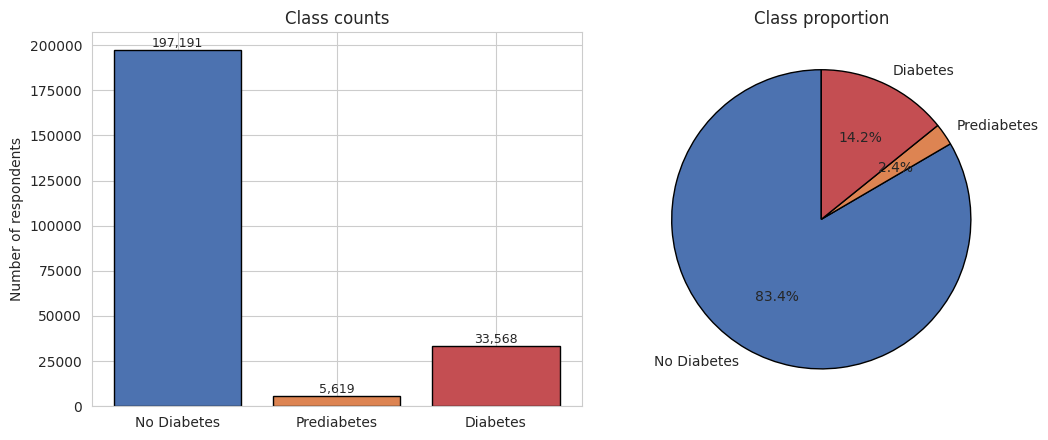

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

order = [0, 1, 2]
colors = ["#4C72B0", "#DD8452", "#C44E52"]

axes[0].bar([target_names[i] for i in order], [counts[i] for i in order], color=colors, edgecolor="black")
axes[0].set_title("Class counts")
axes[0].set_ylabel("Number of respondents")
for i, v in enumerate([counts[o] for o in order]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

axes[1].pie([counts[i] for i in order], labels=[target_names[i] for i in order],
            autopct="%1.1f%%", colors=colors, startangle=90,
            wedgeprops={"edgecolor": "black"})
axes[1].set_title("Class proportion")

plt.tight_layout()
plt.show()


**Takeaway:** the target is heavily imbalanced, and the Prediabetes class in particular is small relative to the other two. Whatever model is built downstream will need to account for this explicitly (class weights, resampling such as SMOTE, or threshold/metric choices) — accuracy alone would be a misleading metric here.

## 4. Feature groups

The explanatory variables split naturally into two groups, which need different treatment during preprocessing and different EDA techniques:

- **Binary indicators** (0/1 survey answers): `HighBP`, `HighChol`, `CholCheck`, `Smoker`, `Stroke`, `HeartDiseaseorAttack`, `PhysActivity`, `Fruits`, `Veggies`, `HvyAlcoholConsump`, `AnyHealthcare`, `NoDocbcCost`, `DiffWalk`, `Sex`
- **Ordinal / continuous-ish features**: `BMI`, `GenHlth`, `MentHlth`, `PhysHlth`, `Age`, `Education`, `Income`

This grouping is derived automatically below (rather than hard-coded) so it stays correct if the source data changes.

In [10]:
feature_cols = [c for c in df_1.columns if c != TARGET]

binary_features = [c for c in feature_cols if df_1[c].dropna().isin([0, 1]).all()]
numeric_features = [c for c in feature_cols if c not in binary_features]

print(f"Binary features ({len(binary_features)}): {binary_features}")
print(f"\nOrdinal/continuous features ({len(numeric_features)}): {numeric_features}")


Binary features (14): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

Ordinal/continuous features (7): ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']


## 5. Distributions of the ordinal / continuous features

The first notebook plotted plain histograms for every column. Here we look specifically at the non-binary features with boxplots (to expose skew and outliers directly) alongside histograms, and report skewness numerically.

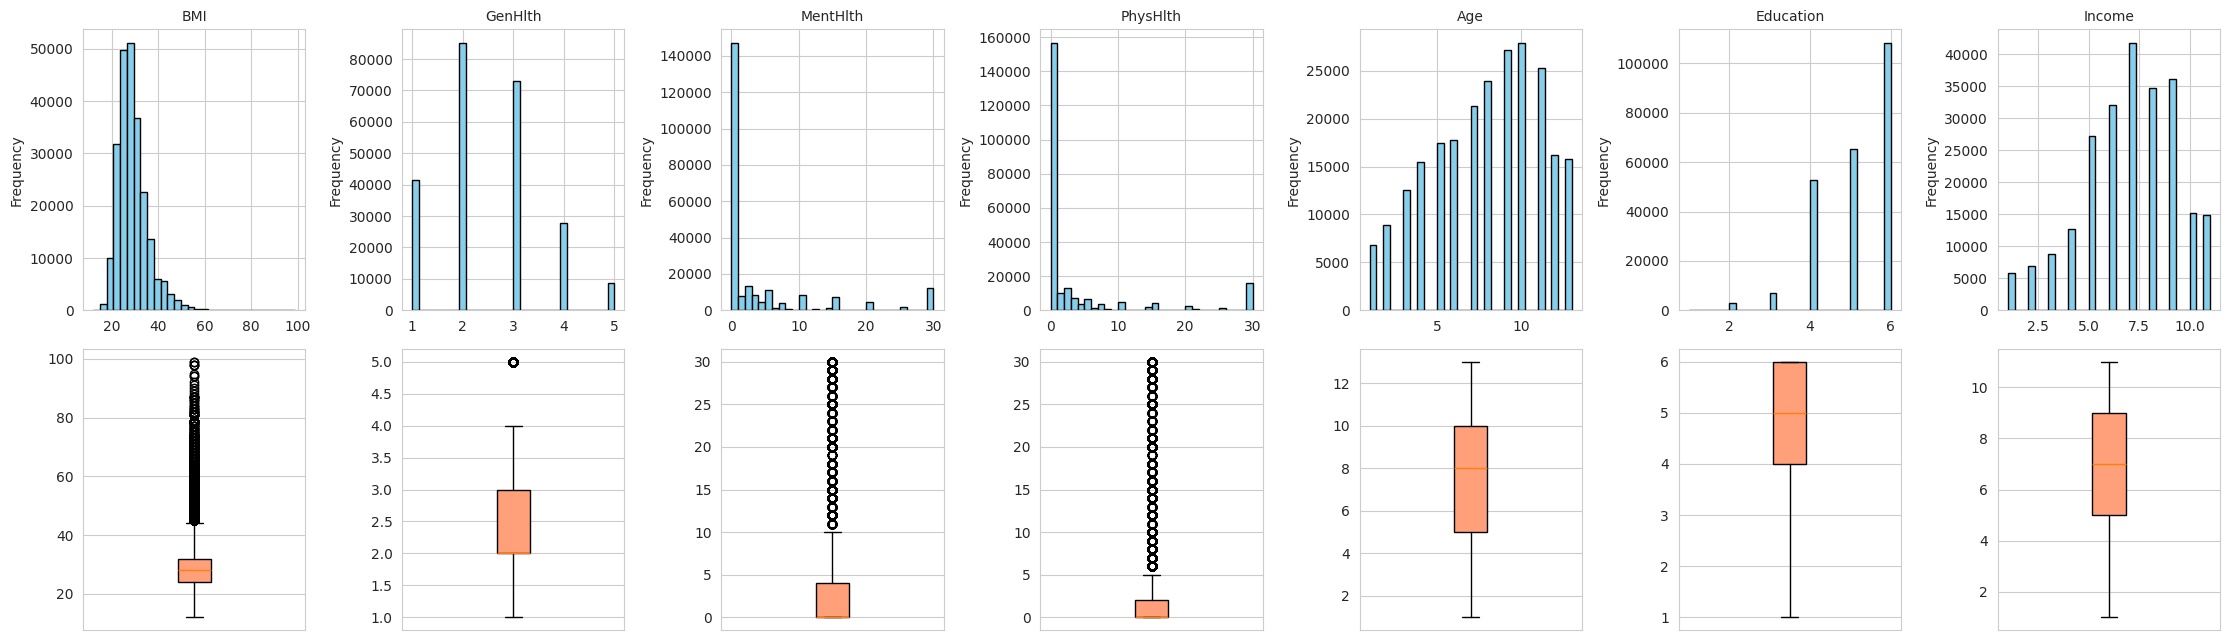

Skewness (>1 or <-1 is strongly skewed):
PhysHlth     2.43
MentHlth     2.32
BMI          1.36
Education   -0.86
Income      -0.41
GenHlth      0.40
Age         -0.31
dtype: float64


In [11]:
fig, axes = plt.subplots(2, len(numeric_features), figsize=(3.2 * len(numeric_features), 6.5))

for j, col in enumerate(numeric_features):
    axes[0, j].hist(df[col], bins=30, color="skyblue", edgecolor="black")
    axes[0, j].set_title(col, fontsize=10)
    axes[0, j].set_ylabel("Frequency")

    axes[1, j].boxplot(df[col], vert=True, patch_artist=True,
                        boxprops=dict(facecolor="lightsalmon"))
    axes[1, j].set_xticks([])

plt.tight_layout()
plt.show()

skew_table = df[numeric_features].skew().sort_values(key=abs, ascending=False).round(2)
print("Skewness (>1 or <-1 is strongly skewed):")
print(skew_table)


## 6. Outlier screening (IQR method)

Flagging, not removing — the decision to cap, transform, or leave outliers alone belongs to the modeling stage. `BMI` is the feature most likely to carry genuine but extreme values (e.g. very high BMI) worth a closer look rather than automatic removal.

In [12]:
def iqr_outlier_report(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    n_out = ((series < lower) | (series > upper)).sum()
    return lower, upper, n_out, round(n_out / len(series) * 100, 2)

outlier_rows = []
for col in numeric_features:
    lower, upper, n_out, pct_out = iqr_outlier_report(df[col])
    outlier_rows.append({"feature": col, "lower_bound": round(lower, 1), "upper_bound": round(upper, 1),
                          "n_outliers": n_out, "pct_outliers": pct_out})

outlier_report = pd.DataFrame(outlier_rows).sort_values("pct_outliers", ascending=False)
print(outlier_report.to_string(index=False))


  feature  lower_bound  upper_bound  n_outliers  pct_outliers
 PhysHlth         -3.0          5.0       38580         16.32
 MentHlth         -6.0         10.0       29178         12.34
  GenHlth          0.5          4.5        8792          3.72
      BMI         12.0         44.0        6314          2.67
      Age         -2.5         17.5           0          0.00
Education          1.0          9.0           0          0.00
   Income         -1.0         15.0           0          0.00


In [13]:
fig = px.box(df, x="Diabetes_label", y="BMI", color="Diabetes_label",
             category_orders={"Diabetes_label": ["No Diabetes", "Prediabetes", "Diabetes"]},
             title="BMI distribution by diabetes class",
             labels={"Diabetes_label": "Diabetes class"})
fig.update_layout(showlegend=False, height=450, width=650)
fig.show()


## 7. Binary feature prevalence by class

The previous notebook computed overall 0/1 proportions for the binary features. Here we break that down **by target class** — this is what actually matters for predictive power: a feature is only useful if its prevalence differs across classes.

In [14]:
prevalence = df.groupby("Diabetes_label")[binary_features].mean().T * 100
prevalence = prevalence[["No Diabetes", "Prediabetes", "Diabetes"]]
prevalence["spread_pp"] = (prevalence["Diabetes"] - prevalence["No Diabetes"]).round(1)
prevalence = prevalence.sort_values("spread_pp", ascending=False).round(1)
print("Percent of class reporting '1' for each binary indicator (spread_pp = Diabetes% - No Diabetes%, in percentage points):")
print(prevalence)


Percent of class reporting '1' for each binary indicator (spread_pp = Diabetes% - No Diabetes%, in percentage points):
Diabetes_label        No Diabetes  Prediabetes  Diabetes  spread_pp
HighBP                       36.0         58.4      73.4       37.4
HighChol                     35.7         58.1      64.0       28.3
DiffWalk                     12.0         24.7      34.0       22.0
HeartDiseaseorAttack          6.5         11.8      20.8       14.3
Smoker                       39.9         44.8      48.1        8.2
Stroke                        3.0          5.1       8.7        5.7
Sex                          47.1         47.1      52.0        5.0
CholCheck                    95.7         98.7      99.5        3.8
AnyHealthcare                96.1         95.7      97.5        1.5
NoDocbcCost                   6.2          8.7       7.2        1.0
HvyAlcoholConsump             6.8          4.6       2.8       -4.0
Fruits                       62.8         59.1      58.7       -4

In [15]:
plot_df = prevalence.drop(columns="spread_pp").reset_index().melt(id_vars="index", var_name="Diabetes_label", value_name="pct_1")
plot_df = plot_df.rename(columns={"index": "feature"})

fig = px.bar(plot_df, x="feature", y="pct_1", color="Diabetes_label", barmode="group",
             category_orders={"Diabetes_label": ["No Diabetes", "Prediabetes", "Diabetes"]},
             labels={"pct_1": "% reporting 1", "feature": ""},
             title="Binary feature prevalence by diabetes class")
fig.update_layout(xaxis_tickangle=-40, height=500, width=1000)
fig.show()


**Takeaway:** features like `HighBP`, `HighChol`, `DiffWalk`, `HeartDiseaseorAttack`, and `Stroke` show a clear, consistent gradient (No Diabetes → Prediabetes → Diabetes), which is a good early signal they'll carry predictive weight. Features with a near-flat spread across classes (e.g. `AnyHealthcare`, `Fruits`, `Veggies` in many BRFSS cuts) are weaker candidates on their own, though they may still interact with other features.

## 8. Statistical association tests: feature vs. target

Two tests, matched to variable type:

- **Chi-square test of independence** for each binary feature vs. the 3-class target.
- **Kruskal–Wallis H-test** (non-parametric ANOVA) for each ordinal/continuous feature vs. the 3-class target, since these variables are not normally distributed (Section 5).

These are screening signals for the modeling stage, not a substitute for it — with ~236k rows, even tiny, practically meaningless effects will come back "significant", so effect size (not just the p-value) is reported too.

In [16]:
chi2_rows = []
for col in binary_features:
    contingency = pd.crosstab(df[col], df[TARGET])
    chi2, p, dof, _ = stats.chi2_contingency(contingency)
    n = contingency.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
    chi2_rows.append({"feature": col, "chi2": round(chi2, 1), "p_value": p, "cramers_v": round(cramers_v, 3)})

chi2_report = pd.DataFrame(chi2_rows).sort_values("cramers_v", ascending=False)
print("Chi-square association with target (Cramer's V effect size: ~0.1 weak, ~0.3 moderate, ~0.5+ strong):")
print(chi2_report.to_string(index=False))


Chi-square association with target (Cramer's V effect size: ~0.1 weak, ~0.3 moderate, ~0.5+ strong):
             feature    chi2       p_value  cramers_v
              HighBP 17145.1  0.000000e+00      0.269
            DiffWalk 11065.1  0.000000e+00      0.216
            HighChol 10325.4  0.000000e+00      0.209
HeartDiseaseorAttack  7463.7  0.000000e+00      0.178
        PhysActivity  5436.7  0.000000e+00      0.152
              Stroke  2501.9  0.000000e+00      0.103
           CholCheck  1252.0 1.326521e-272      0.073
              Smoker   821.8 3.518246e-179      0.059
   HvyAlcoholConsump   820.8 5.722255e-179      0.059
             Veggies   543.7 8.819374e-119      0.048
                 Sex   282.8  3.992862e-62      0.035
              Fruits   225.6  1.009966e-49      0.031
       AnyHealthcare   183.2  1.678596e-40      0.028
         NoDocbcCost    98.9  3.303731e-22      0.020


In [17]:
kw_rows = []
for col in numeric_features:
    groups = [df.loc[df[TARGET] == c, col] for c in [0, 1, 2]]
    h_stat, p = stats.kruskal(*groups)
    eta_sq = (h_stat - 2) / (len(df) - 3)  # epsilon-squared approx effect size for Kruskal-Wallis
    kw_rows.append({"feature": col, "H_statistic": round(h_stat, 1), "p_value": p, "epsilon_sq": round(max(eta_sq, 0), 3)})

kw_report = pd.DataFrame(kw_rows).sort_values("epsilon_sq", ascending=False)
print("Kruskal-Wallis association with target:")
print(kw_report.to_string(index=False))


Kruskal-Wallis association with target:
  feature  H_statistic      p_value  epsilon_sq
  GenHlth      18941.9 0.000000e+00       0.080
      BMI      10606.0 0.000000e+00       0.045
      Age       9196.4 0.000000e+00       0.039
   Income       6060.7 0.000000e+00       0.026
 PhysHlth       4837.6 0.000000e+00       0.020
Education       2763.0 0.000000e+00       0.012
 MentHlth         33.6 5.059085e-08       0.000


## 9. Correlation structure & multicollinearity

Two related but distinct questions for the modeling stage:

1. **Are any features redundant with each other** (which matters for linear/logistic models, and for feature selection generally)?
2. **Variance Inflation Factor (VIF)** — a more rigorous multicollinearity check than pairwise correlation alone, since it captures multivariate redundancy.

Spearman correlation is used (not Pearson) since most features are binary/ordinal rather than continuous.

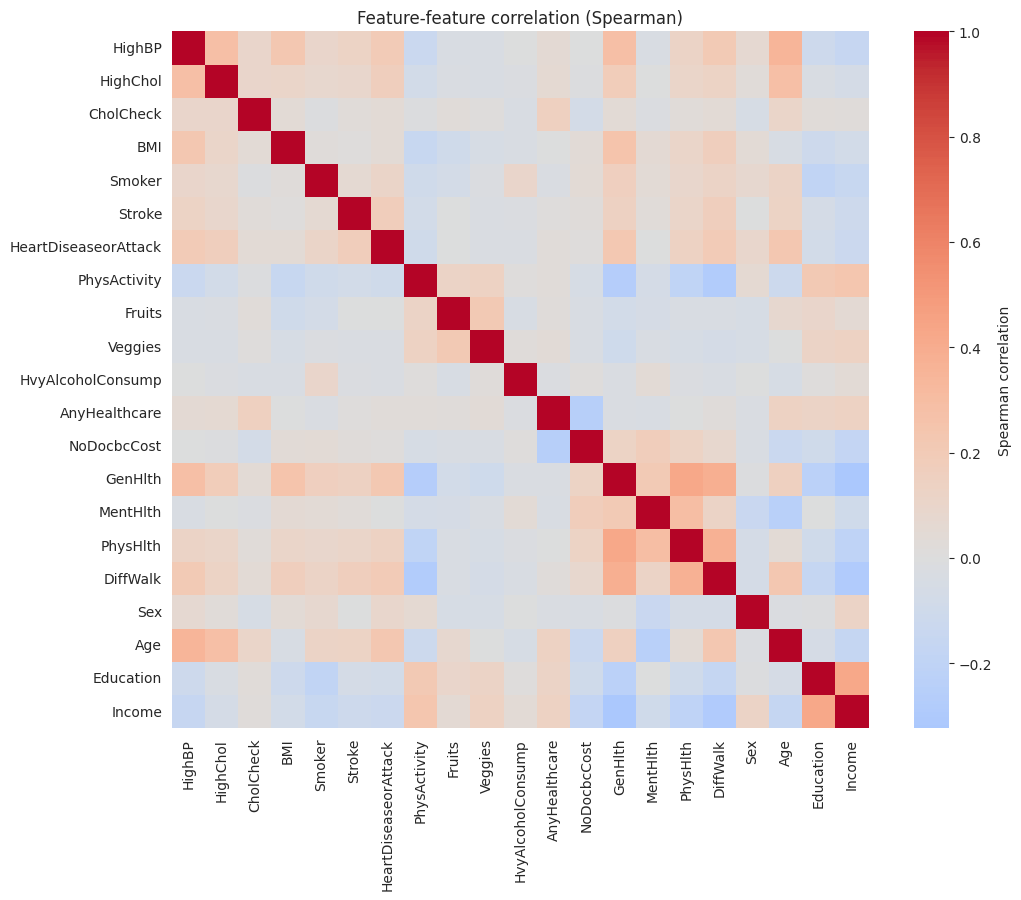

Top 10 most correlated feature pairs:
GenHlth       PhysHlth    0.430059
Education     Income      0.429828
GenHlth       DiffWalk    0.386944
PhysHlth      DiffWalk    0.372152
HighBP        Age         0.344432
GenHlth       Income     -0.323452
MentHlth      PhysHlth    0.292235
DiffWalk      Income     -0.289378
PhysActivity  DiffWalk   -0.284294
HighChol      Age         0.283915
dtype: float64


In [18]:
corr = df[feature_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True,
            cbar_kws={"label": "Spearman correlation"}, ax=ax)
ax.set_title("Feature-feature correlation (Spearman)")
plt.tight_layout()
plt.show()

corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(key=abs, ascending=False)
print("Top 10 most correlated feature pairs:")
print(corr_pairs.head(10))


In [19]:
from sklearn.preprocessing import StandardScaler

X_vif = df[feature_cols].dropna()
X_vif_scaled = StandardScaler().fit_transform(X_vif)

vif_data = pd.DataFrame()
vif_data["feature"] = feature_cols
vif_data["VIF"] = [variance_inflation_factor(X_vif_scaled, i) for i in range(X_vif_scaled.shape[1])]
vif_data = vif_data.sort_values("VIF", ascending=False).round(2)
print("Variance Inflation Factor (VIF > 5 warrants a look, > 10 is a strong multicollinearity signal):")
print(vif_data.to_string(index=False))


Variance Inflation Factor (VIF > 5 warrants a look, > 10 is a strong multicollinearity signal):
             feature  VIF
             GenHlth 1.69
            PhysHlth 1.54
            DiffWalk 1.47
              Income 1.45
                 Age 1.42
              HighBP 1.32
           Education 1.30
            MentHlth 1.23
        PhysActivity 1.20
            HighChol 1.17
                 BMI 1.16
HeartDiseaseorAttack 1.15
         NoDocbcCost 1.14
       AnyHealthcare 1.13
              Smoker 1.10
             Veggies 1.08
              Fruits 1.08
                 Sex 1.07
              Stroke 1.07
           CholCheck 1.05
   HvyAlcoholConsump 1.02


**Takeaway:** no pair of features is severely collinear enough on its own to require dropping either one outright, and VIF values stay in a range that doesn't demand it either — worth re-checking once any engineered/interaction features are added later, but the raw feature set looks safe to feed into most model types as-is.

## 10. Preliminary feature relevance screen (mutual information)

Mutual information captures non-linear relationships that correlation and the pairwise tests above can miss, and ranks every feature — binary and ordinal alike — on a single common scale against the 3-class target. This is a **screening tool**, not feature selection for a final model; it's meant to flag which features look most informative before modeling starts, and to catch any that look surprisingly uninformative and worth double-checking.

In [20]:
X_mi = df[feature_cols].dropna()
y_mi = df.loc[X_mi.index, TARGET]

mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features=[c in binary_features for c in feature_cols],
                                 random_state=RANDOM_STATE)
mi_report = pd.DataFrame({"feature": feature_cols, "mutual_info": mi_scores}).sort_values("mutual_info", ascending=False)
mi_report["mutual_info"] = mi_report["mutual_info"].round(4)
print(mi_report.to_string(index=False))


             feature  mutual_info
             GenHlth       0.0508
              HighBP       0.0363
                 Age       0.0289
                 BMI       0.0247
            HighChol       0.0214
           Education       0.0203
            DiffWalk       0.0197
              Income       0.0189
            PhysHlth       0.0136
HeartDiseaseorAttack       0.0126
        PhysActivity       0.0104
              Stroke       0.0042
           CholCheck       0.0038
            MentHlth       0.0028
   HvyAlcoholConsump       0.0021
              Smoker       0.0017
             Veggies       0.0011
                 Sex       0.0006
              Fruits       0.0005
       AnyHealthcare       0.0004
         NoDocbcCost       0.0002


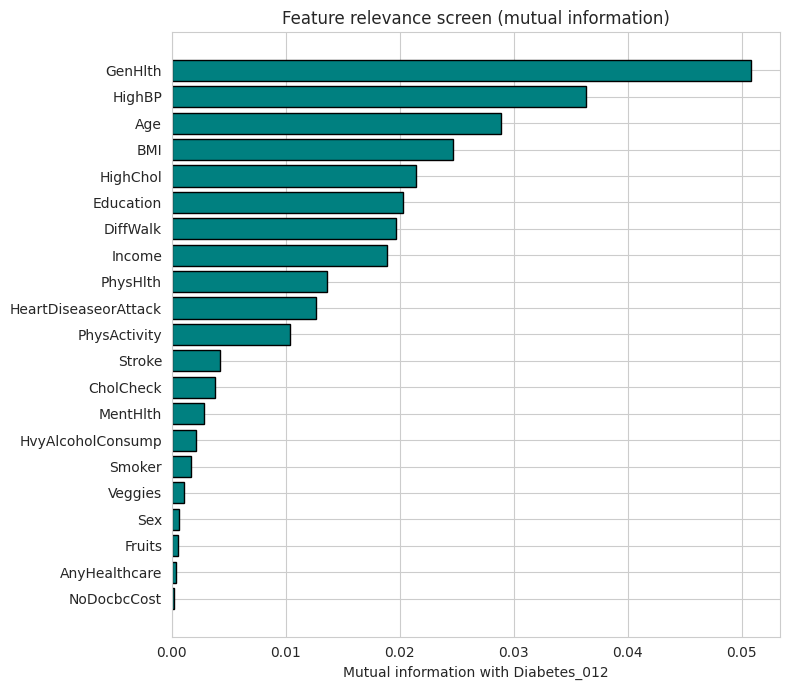

In [21]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(mi_report["feature"][::-1], mi_report["mutual_info"][::-1], color="teal", edgecolor="black")
ax.set_xlabel("Mutual information with Diabetes_012")
ax.set_title("Feature relevance screen (mutual information)")
plt.tight_layout()
plt.show()


## 11. Cross-check against the binary-label datasets

Quick consistency check between the 3-class dataset used above and the two binary datasets from the first notebook: does collapsing `Diabetes_012` to binary (0 vs. {1,2}) roughly match the class balance and top-feature story in `df_3` (the full, imbalanced binary dataset), and does `df_2`'s 50/50 split look like a plain resample rather than a different population?

In [22]:
collapsed = df[TARGET].apply(lambda v: 0 if v == 0 else 1)
print("df_1 collapsed to binary (0 = No Diabetes, 1 = Prediabetes or Diabetes):")
print(collapsed.value_counts(normalize=True).round(4) * 100)

print("\ndf_3 (Diabetes_binary, full dataset) for comparison:")
print(df_3["Diabetes_binary"].value_counts(normalize=True).round(4) * 100)

print("\ndf_2 (Diabetes_binary, 5050 split) for comparison:")
print(df_2["Diabetes_binary"].value_counts(normalize=True).round(4) * 100)

print(f"\ndf_2 row count is roughly 2x the positive-class count of df_3: "
      f"{len(df_2):,} vs. 2 x {int(df_3['Diabetes_binary'].sum()):,} = {2*int(df_3['Diabetes_binary'].sum()):,}")


df_1 collapsed to binary (0 = No Diabetes, 1 = Prediabetes or Diabetes):
Diabetes_012
0    83.42
1    16.58
Name: proportion, dtype: float64

df_3 (Diabetes_binary, full dataset) for comparison:
Diabetes_binary
0.0    85.8
1.0    14.2
Name: proportion, dtype: float64

df_2 (Diabetes_binary, 5050 split) for comparison:
Diabetes_binary
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64

df_2 row count is roughly 2x the positive-class count of df_3: 67,136 vs. 2 x 33,568 = 67,136


**Takeaway:** the collapsed binary rate from `df_1` and the class rate in `df_3` line up closely, and `df_2`'s row count matches an undersample of the majority class to match the minority count — consistent with `df_2` being a balanced resample of the same underlying population rather than a distinct data source. Good sign that `df_1` alone is a safe, representative base for the 3-class model.

## 12. Summary & handoff notes for the modeling stage

**Data quality**
- No missing values in any column.
- A number of fully duplicated rows exist; expected in a survey with mostly binary/ordinal answers, but confirm before/after-split handling to avoid leakage.
- No constant columns.

**Target**
- 3 classes, substantially imbalanced — Prediabetes is the minority class by a wide margin. Plan for class weighting, resampling, and/or a metric other than plain accuracy (e.g. macro-F1, balanced accuracy) from the start.

**Features**
- 14 binary indicators, 7 ordinal/continuous features (`BMI`, `GenHlth`, `MentHlth`, `PhysHlth`, `Age`, `Education`, `Income`).
- `BMI`, `MentHlth`, `PhysHlth` are right-skewed with a non-trivial share of IQR-flagged outliers — consider a transform (log/Box-Cox) or robust scaling rather than dropping these outright.
- Chi-square/Kruskal-Wallis and the mutual-information screen broadly agree on the strongest candidate predictors (led by general-health rating, high blood pressure, high cholesterol, BMI, and difficulty walking); a few binary features look weak in isolation and are candidates for interaction terms or exclusion, to be confirmed during modeling.
- No severe pairwise or multivariate (VIF) collinearity in the raw feature set.

**Not done here, by design:** any train/test split, scaling/encoding actually applied to a modeling matrix, resampling, model training, or hyperparameter tuning. This notebook stops at the diagnostics needed to make those decisions well.
